## This notebook tests Bayes-SCF for different smoothing scale. This notebook runs on one configuration (NOFLAG) and genertes the simulated data. It also estimates the power spectrum from the input data and plots.  

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["VECLIB_MAXIMUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import nuttall
from matplotlib.colors import LogNorm
import pkfuncs as pfunc
import scipy
from scipy.signal import windows
import plot_scripts as plts
import os
plt.style.use("mplstyle")

In [2]:
# input model power spectrum
n = 2.0
N = 768
dnuc = 40e-3            # MHz
r = 9209.714526830916 # Mpc
rp = 16.98990953034521  # Mpc/MHz
dL = dnuc * rp
L  = N * dL
Nrea = 100

# EoR 21-cm PS for Mondal+17
PK21 = np.load('PK21.npy')
k_model = PK21[:, 0]
P_model = PK21[:, 1]
# P_model = k_model**(-n)


k_fft = 2*np.pi*np.arange(N)/L

# kper = 0.1
# k_fft = np.sqrt( k_fft**2 + kper**2 ) 

k_abs = np.abs(k_fft)

P_cont = np.interp(k_abs, k_model, P_model , left=0, right=0)

# Discrete variance for FFT modes
P_dft = (N**2 / L) * P_cont 
# P_dft = L * P_cont 
# P_dft = P_cont 

# binning 
NB = 64  # number of bins
NN_gp = 32
NN_gp = 64
NN_gp = 96
# NN_gp = 112
# NN_gp = 128

In [3]:
# INP_SIGNAL_CONFIGS = {
#     "21cm": dict(type="21cm"),
#     "FG+21cm": dict(type="FG+21cm"),
#     "FG+MM+21cm": dict(type="FG+MM+21cm"),
# }
INP_SIGNAL_CONFIGS = {
    # "21cm": dict(type="21cm"),
    "FG+MM+21cm": dict(type="FG+MM+21cm"),
}

# # -----------------------------
# # FLAG configurations
# # -----------------------------
# FLAG_CONFIGS = {
#     "NOFLAG": dict(mode="NOFLAG", percent=0, seed=42),
#     "RANDOM35": dict(mode="RANDOM", percent=35, seed=42),
#     "PERIODIC": dict(mode="PERIODIC", percent=0, seed=42),
#     "PERIODIC+RANDOM10": dict(mode="PERIODIC+RANDOM", percent=10, seed=42),
# }
FLAG_CONFIGS = {
    "NOFLAG": dict(mode="NOFLAG", percent=0, seed=42),
}

# # -----------------------------
# # SCF configurations
# # -----------------------------
# SCF_CONFIGS = {
#     "None": dict(SCF="None", NN_gp=None, NN_hann=None),
#     "GP":   dict(SCF="GP",   NN_gp=96,  NN_hann=None),
#     "Hann": dict(SCF="Hann", NN_gp=None, NN_hann=50),
# }

SCF_CONFIGS = {
    "GP":   dict(SCF="GP",   NN_gp=NN_gp,  NN_hann=None),
}


In [4]:
def generate_fields(inp_signal, *, N, Nrea, P_dft):
    # 21-cm realizations (always needed)
    fields_21cm = np.array(
        [pfunc.draw_field_from_power(P_dft, seed=55 + i) for i in range(Nrea)]
    )

    if inp_signal == "21cm":
        return fields_21cm

    if inp_signal == "FG+21cm":
        fields_forg = pfunc.generate_gp_realizations(
            Npoints=N,
            amplitude=1e12,
            length_scale=1e4,
            Nreal=Nrea,
            kernel_type="RBF",
            sigma=1, seed=42,
        )
        return fields_forg + fields_21cm

    if inp_signal == "FG+MM+21cm":
        fields_forg = pfunc.generate_gp_realizations(
            Npoints=N,
            amplitude=1e12,
            length_scale=100,
            Nreal=Nrea,
            kernel_type="RBF",
            sigma=1, seed=42,
        )
        return fields_forg + fields_21cm

    raise ValueError(f"Unknown inp_signal: {inp_signal}")


In [5]:
# fname = f"fft_inp_signal-{inp_signal}_flag-{flag}_SCF-{SCF}_NN-{NN_gp}.npz"
# fname

In [6]:
def run_one_configuration(
    fields_tota,
    inp_signal,
    flag_cfg,
    scf_cfg,
    *,
    N, L, dL, r, NB,
    k_model, P_model,
    P_cont, k_abs,
    path="results"
):
    # -----------------------------
    os.makedirs(path, exist_ok=True)
    # -----------------------------
    flag = pfunc.flagdata(
        N,
        mode=flag_cfg["mode"],
        percent=flag_cfg["percent"],
        seed=flag_cfg["seed"],
    )

    flag_percent = 100 * (1 - np.count_nonzero(flag) / N)
    print(
        f"[FLAG={flag_cfg['mode']}, SCF={scf_cfg['SCF']}] "
        f"flagged = {flag_percent:.1f}%"
    )

    # -----------------------------
    # SCF processing
    # -----------------------------
    fields_tota = fields_tota*flag
    fields_orig, fields_flag, ml = pfunc.process_scf(
        fields_tota,
        flag,
        scf_cfg["SCF"],
        NN_gp=scf_cfg["NN_gp"],
        NN_hann=scf_cfg["NN_hann"], verbose=True
    )
    
    # plt.plot(fields_orig[0])
    # plt.show()
    
    # -----------------------------
    # FFT estimator
    # -----------------------------
    pk_fft = pfunc.pk_fft(fields_flag, L, N)

    n1_fft, nend_fft = 0, N // 2
    kb_fft, mean_fft, err_fft, binned_th_fft, _ = pfunc.bin_power_spectrum(
        n1_fft, nend_fft,
        k_abs[n1_fft:nend_fft],
        pk_fft,
        P_cont,
        NB
    )

    # -----------------------------
    # DCT estimator
    # -----------------------------
    M = np.argmax(ml.real == 0) if np.any(ml.real == 0) else ml.shape[0]
    k_dct = np.pi * np.arange(M) / ((M - 1) * dL)
    # print(k_dct)
    
    P_cont_dct = np.interp(k_dct, k_model, P_model, left=0, right=0)
    w = windows.nuttall(2*M)[M:]
    pk_dct, cl = pfunc.pk_dct(fields_flag, dL, ml, M, r, w)

    kb_dct, mean_dct, err_dct, binned_th_dct, _ = pfunc.bin_power_spectrum(
        0, M, k_dct, pk_dct, P_cont_dct, NB
    )

    # -----------------------------
    # Save outputs
    # -----------------------------
    flag_name = flag_cfg["mode"]
    SCF = scf_cfg["SCF"]

    # Construct filename matching your save_data style
    fields_fname = f"{path}/fields_inp_signal-{inp_signal}_flag-{flag_name}_SCF-{SCF}_NN-{NN_gp}.npz"

    # Only save if the file does not exist
    # if not os.path.exists(fields_fname):
    # print(f"Saving fields to {fields_fname}...")
    np.savez(
        fields_fname,
        fields_tota=fields_tota,
        fields_orig=fields_orig,
        fields_flag=fields_flag,
        # Metadata (optional but helpful)
        inp_signal=inp_signal,
        flag=flag_name,
        SCF=SCF
    )

    pfunc.save_data(
        fname_prefix = f"{path}/fft",
        inp_signal=inp_signal,
        flag=flag_name,
        SCF=SCF,
        kb=kb_fft,
        mean=mean_fft,
        err=err_fft,
        binned_th=binned_th_fft,
        fname = f"{path}/fft_inp_signal-{inp_signal}_flag-{flag_name}_SCF-{SCF}_NN-{NN_gp}.npz"
    )

    pfunc.save_data(
        fname_prefix = f"{path}/dct",
        inp_signal=inp_signal,
        flag=flag_name,
        SCF=SCF,
        kb=kb_dct,
        mean=mean_dct,
        err=err_dct,
        binned_th=binned_th_dct,
        fname = f"{path}/dct_inp_signal-{inp_signal}_flag-{flag_name}_SCF-{SCF}_NN-{NN_gp}.npz"
    )

    np.savez(
        # f"{path}/CL_inp_signal-{inp_signal}_flag-{flag_name}_SCF-{SCF}.npz",
        f"{path}/CL_inp_signal-{inp_signal}_flag-{flag_name}_SCF-{SCF}_NN-{NN_gp}.npz",
        cl=cl,
        inp_signal=inp_signal,
        flag=flag,
        SCF=SCF,
    )



In [7]:
# from tqdm.notebook import tqdm  # Use 'tqdm' if running in a script
from tqdm import tqdm

# Wrap your outer loop with tqdm
for inp_signal in tqdm(INP_SIGNAL_CONFIGS, desc="Signals"):

    print(f"\n=== Running inp_signal = {inp_signal} ===")
    
    fields_tota = generate_fields(
        inp_signal,
        N=N, Nrea=Nrea, P_dft=P_dft,
    )

    

    # You can also wrap inner loops if they are long
    for flag_key, flag_cfg in FLAG_CONFIGS.items():
        for scf_key, scf_cfg in SCF_CONFIGS.items():
            
            run_one_configuration(
                fields_tota=fields_tota,
                inp_signal=inp_signal,
                flag_cfg=flag_cfg,
                scf_cfg=scf_cfg,
                N=N, L=L, dL=dL, r=r, NB=NB,
                k_model=k_model,
                P_model=P_model,
                P_cont=P_cont,
                k_abs=k_abs,
                path="results_NN_gp",
            )


Signals:   0%|                                                                                    | 0/1 [00:00<?, ?it/s]


=== Running inp_signal = FG+MM+21cm ===
[FLAG=NOFLAG, SCF=GP] flagged = 0.0%
(768,)


Signals: 100%|██████████████████████████████████████████████████████████████████████████| 1/1 [35:38<00:00, 2138.17s/it]


In [8]:
import numpy as np

data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
summaries = data["summaries"]
amp_smooth = np.array([s["amp_smooth"] for s in summaries])
amp_fast   = np.array([s["amp_fast"] for s in summaries])
ell_fast   = np.array([s["ell_fast"] for s in summaries])
ell_ratio  = np.array([s["ell_fast_over_NN"] for s in summaries])
logL       = np.array([s["logL"] for s in summaries])
y_std      = np.array([s["y_std"] for s in summaries])
y_res_std  = np.array([s["y_res_std"] for s in summaries])
success    = np.array([s["success"] for s in summaries])

In [9]:
# Plot

In [10]:
def FGname(inp_signal):
    if (inp_signal == '21cm'):
        FG = 'None'
        dataname = '21cm'
    elif (inp_signal == 'FG+21cm'):
        FG = 'Smooth'
        dataname = 'FG'
    elif (inp_signal == 'FG+MM+21cm'):
        FG = 'Unsmooth'
        dataname = 'FGMM'
    return FG, dataname

inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
Saved: plots/FGMM_GP_NN.pdf


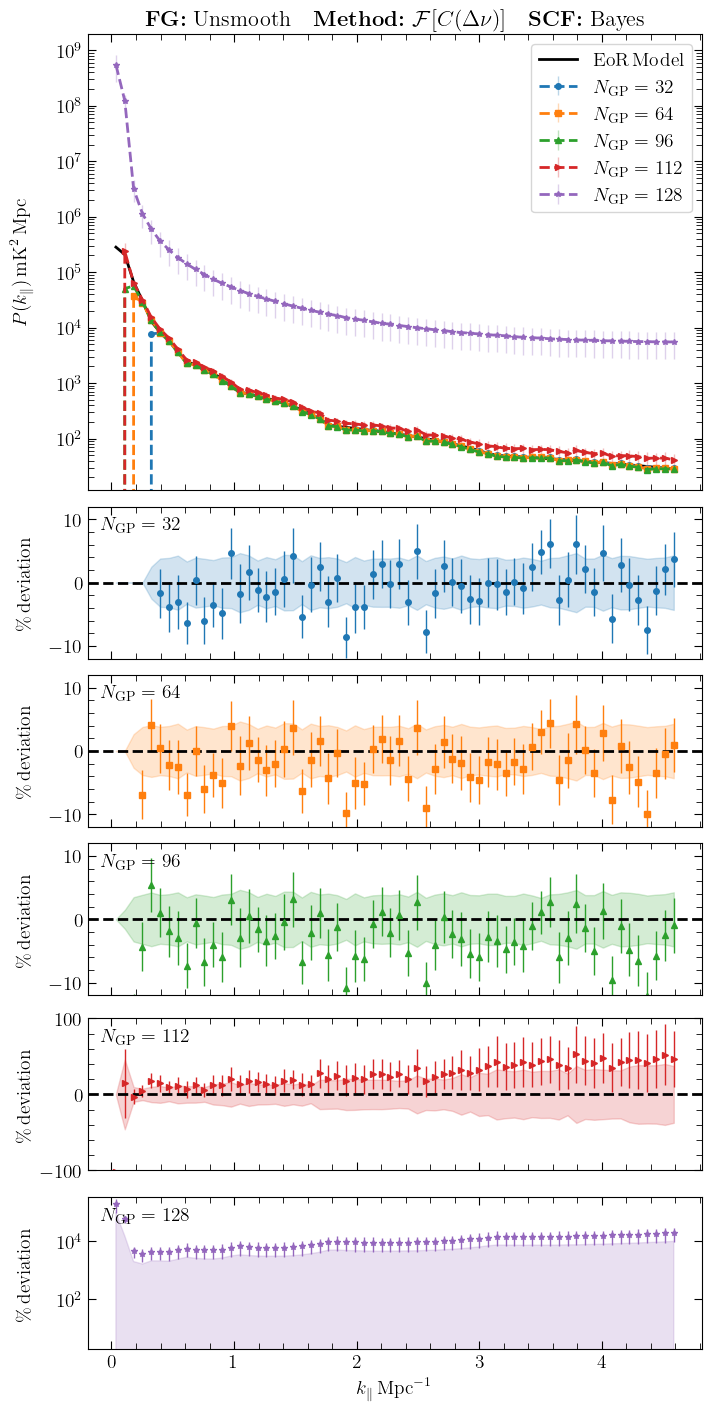

In [11]:
inp_signal = "21cm"
inp_signal = "FG+MM+21cm"
SCF        = "GP"
path       = "results_NN_gp"
modes  = ['NOFLAG']
# colors = ['C1']
# fmts = ['s']


modes  = [32, 64, 96, 112, 128]
colors = ['C0', 'C1', 'C2', 'C3', 'C4']
fmts = ['o', 's', '^', '>', '*']


FG, dataname = FGname(inp_signal)
shift, ylim = 1.0, 210
shift, ylim = 1.0, 12
 
figname = f"plots/{dataname}_{SCF}_NN.pdf"
os.makedirs("plots", exist_ok=True)

# --------------------------------------------------
# FIGURE LAYOUT
# --------------------------------------------------
fig = plt.figure(figsize=(7, 14))
gs  = fig.add_gridspec(
    6, 1,
    height_ratios=[3, 1, 1, 1, 1, 1],
    hspace=0.07
)

ax1 = fig.add_subplot(gs[0])
axd = [fig.add_subplot(gs[i], sharex=ax1) for i in range(1, 6)]


# --------------------------------------------------
# LOOP OVER FLAG PATTERNS
# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):

    # ---------- Load data ----------
    data = np.load(
        f"{path}/dct_inp_signal-{inp_signal}_flag-NOFLAG_SCF-GP_NN-{mode}.npz"
    )

    kb_fft        = data["kb"]
    mean_fft      = data["mean"]
    err_fft       = data["err"]
    binned_th_fft = data["binned_th"]

    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()

    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")

    # ---------- TOP PANEL: power spectra ----------
    ax1.errorbar(
        kb_fft,
        (mean_fft) * shift,
        err_fft * shift,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        ls='--',
        color=color,
        ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.3),  # transparent error bars
        label=fr"$N_{{\rm GP}} = \rm{{ {mode} }}$" 

    )


    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )

    # ---------- Deviation ----------
    ratio = 100.0 * (mean_fft / binned_th_fft - 1.0)
    err_r = 100.0 * err_fft / binned_th_fft

    axd[i].errorbar(
        kb_fft,
        ratio,
        err_r,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        color=color
    )

    # if i != 4:
    axd[i].fill_between(kb_fft, -err_r, err_r,
                        color=color, alpha=0.2,
                        label="_nolegend_")

    axd[i].axhline(0, color='k', ls='--')
    # axd[i].grid(alpha=0.3)
    axd[i].set_ylabel(r'\rm{\%\,deviation}')
    # axd[i].set_xscale('log')

    axd[i].text(
        0.02, 0.85,
        fr"$N_{{\rm GP}} = \rm{{ {mode} }}$",
        transform=axd[i].transAxes,
        # fontsize=10
    )

    if ylim is not None:
        if i!=4:
            axd[i].set_ylim(-ylim, ylim)
    
    # axd[-1].set_ylim(1e3, 3e5)
    axd[-2].set_ylim(-1e2, 1e2)
    axd[-1].set_yscale('log')

    
# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_ylabel(r'$ P(k_\parallel) \,{\rm mK}^2\,{\rm Mpc}$')
# ax1.grid(alpha=0.3)
ax1.legend()
ax1.tick_params(labelbottom=False)

for ax in axd[:-1]:
    ax.tick_params(labelbottom=False)

axd[-1].tick_params(labelbottom=True)


axd[-1].set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')

SCF = 'Bayes'
ax1.set_title(
    r"\rm{{\bf FG:}~}" + fr"\rm{{{FG}}}"
    + r"\rm{\quad {\bf Method:}~}" + r'${ \mathcal{F} [ C(\Delta\nu) ] }$'
    + r"\rm{\quad {\bf SCF:}~}" + fr"$\mathrm{{{SCF}}}$",
    
)

fig.align_ylabels()
fig.savefig(figname, bbox_inches='tight')
print("Saved:", figname)


inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
inp_signal = FG+MM+21cm, flag = NOFLAG, scf = GP
Saved: plots/FGMM_GP_NN_zoom.pdf


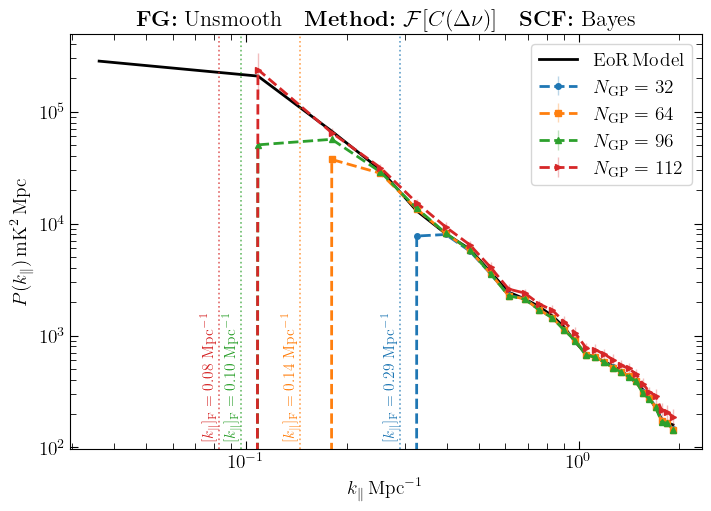

In [12]:
inp_signal = "21cm"
inp_signal = "FG+MM+21cm"
SCF        = "GP"
path       = "results_NN_gp"
modes  = ['NOFLAG']
# colors = ['C1']
# fmts = ['s']
modes  = [32, 64, 96, 112]
colors = ['C0', 'C1', 'C2', 'C3']
fmts = ['o', 's', '^', '>']
FG, dataname = FGname(inp_signal)
shift, ylim = 1.0, 210
shift, ylim = 1.0, 12
# r' [Mpc/MHz] used in the theoretical N_GP <-> k_parallel relation:
#   N_GP = 2*pi / (r' * dnuc * [k_par]_H)
#   =>    [k_par]_H = 2*pi / (r' * dnuc * N_GP)
r_prime = rp
figname = f"plots/{dataname}_{SCF}_NN_zoom.pdf"
os.makedirs("plots", exist_ok=True)
# --------------------------------------------------
# FIGURE LAYOUT (single panel)
# --------------------------------------------------
fig, ax1 = plt.subplots(figsize=(7, 5))
# --------------------------------------------------
# LOOP OVER FLAG PATTERNS
# --------------------------------------------------
for i, (mode, color, fmt) in enumerate(zip(modes, colors, fmts)):
    # ---------- Load data ----------
    data = np.load(
        f"{path}/dct_inp_signal-{inp_signal}_flag-NOFLAG_SCF-GP_NN-{mode}.npz"
    )
    n1 = 27
    kb_fft        = data["kb"][:n1]
    mean_fft      = data["mean"][:n1]
    err_fft       = data["err"][:n1]
    binned_th_fft = data["binned_th"][:n1]
    inp_signal1 = data["inp_signal"].tolist()
    flag1       = data["flag"].tolist()
    scf1        = data["SCF"].tolist()
    print(f"inp_signal = {inp_signal1}, flag = {flag1}, scf = {scf1}")
    # ---------- TOP PANEL: power spectra ----------
    ax1.errorbar(
        kb_fft,
        (mean_fft) * shift,
        err_fft * shift,
        ms=4,
        elinewidth=1,
        fmt=fmt,
        ls='--',
        color=color,
        ecolor=(*plt.matplotlib.colors.to_rgb(color), 0.3),  # transparent error bars
        label=fr"$N_{{\rm GP}} = \rm{{ {mode} }}$"
    )
    if i == 0:
        ax1.plot(
            kb_fft,
            binned_th_fft * shift,
            '-k',
            lw=2,
            label=r'${\rm EoR\,Model}$'
        )
    # ---------- Theoretical k_parallel for this N_GP ----------
    # [k_par]_F = 2*pi / (r' * dnuc * N_GP)   (fundamental, n=1)
    k_par_theory =  2.0 * np.pi / (rp * dnuc * mode)
    ax1.axvline(k_par_theory, color=color, ls=':', lw=1.2, alpha=0.7)
    ax1.text(
        k_par_theory, .02,
        fr"$[k_\parallel]_{{\rm F}} = {k_par_theory:.2f}\ \mathrm{{Mpc}}^{{-1}}$",
        transform=ax1.get_xaxis_transform(),
        color=color, rotation=90, ha='right', va='bottom', zorder=11,
        fontsize=11,
    )
# --------------------------------------------------
ax1.set_yscale('log')
ax1.set_xscale('log')
ax1.set_ylabel(r'$ P(k_\parallel) \,{\rm mK}^2\,{\rm Mpc}$')
ax1.set_xlabel(r'$k_\parallel\,{\rm Mpc}^{-1}$')
# ax1.grid(alpha=0.3)
ax1.legend()
SCF = 'Bayes'
ax1.set_title(
    r"\rm{{\bf FG:}~}" + fr"\rm{{{FG}}}"
    + r"\rm{\quad {\bf Method:}~}" + r'${ \mathcal{F} [ C(\Delta\nu) ] }$'
    + r"\rm{\quad {\bf SCF:}~}" + fr"$\mathrm{{{SCF}}}$",
)
fig.savefig(figname, bbox_inches='tight')
print("Saved:", figname)

In [13]:
k_par_theory

0.08254880450349811

In [23]:
# import numpy as np
# import matplotlib.pyplot as plt
# # ---- NN list ----
# NN_list = [32, 64, 96, 112, 128]
# nN = len(NN_list)
# # ---- SCALE FACTORS ----
# scale_AS2 = 1e12
# scale_AF2 = 1e3
# scale_ell = 1
# # ---- FIGURE: rows = NN, cols = params ----
# # sharey='row' keeps the y-axis scale consistent within each NN_GP row,
# # which is the only place sharing counts actually makes sense (different
# # rows can have very different sample sizes / bin counts).
# fig, axes = plt.subplots(nN, 3, figsize=(12, 3 * nN), sharey='row')
# for i, NN_gp in enumerate(NN_list):
#     data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
#     summaries = data["summaries"]
#     # =========================
#     # Column 0: A_S^2
#     # =========================
#     A_S = np.array([s["amp_smooth"] for s in summaries])
#     y_std = np.array([s["y_std"] for s in summaries])
#     AS2 = A_S
#     y_var = y_std ** 2
#     med_AS2 = np.median(AS2)
#     med_yv = np.median(y_var)
#     AS2_plot = AS2 / scale_AS2
#     y_var_plot = y_var / scale_AS2
#     ax = axes[i, 0]
#     bins = np.linspace(AS2_plot.min(), AS2_plot.max(), 15)
#     ax.hist(AS2_plot, bins=bins, histtype='step', linewidth=1.5)
#     ax.axvline(med_AS2 / scale_AS2, linestyle='--', linewidth=1.5,
#                label=r"$\mathrm{med}(A_{\mathrm S}^2)$")
#     ax.axvline(med_yv / scale_AS2, linestyle=':', linewidth=2.0, color='k',
#                label=r"$\mathrm{med}(\sigma_y^2)$")
#     ax.set_xscale('log')
#     if i == 0:
#         ax.legend()
#     # Row label (N_GP=...) placed outside the right edge of the LAST column,
#     # not fighting with the y-axis "Count" label on the left.
#     axes[i, 2].annotate(
#         rf"$N_{{\rm GP}}={NN_gp}$",
#         xy=(1.02, 0.5), xycoords='axes fraction',
#         rotation=270, va='center', ha='left', 
#     )
#     # =========================
#     # Column 1: A_F^2
#     # =========================
#     A_F = np.array([s["amp_fast"] for s in summaries])
#     y_res_std = np.array([s["y_res_std"] for s in summaries])
#     y_res_var = y_res_std ** 2
#     AF2 = (A_F / y_res_var) * y_var
#     med_AF2 = np.median(AF2)
#     med_yres = np.median(y_res_var)
#     AF2_plot = AF2 / scale_AF2
#     y_res_plot = y_res_var / scale_AF2
#     ax = axes[i, 1]
#     bins = np.linspace(AF2_plot.min(), AF2_plot.max(), 15)
#     ax.hist(AF2_plot, bins=bins, histtype='step', linewidth=1.5)
#     ax.axvline(med_AF2 / scale_AF2, linestyle='--', linewidth=1.5,
#                label=r"$\mathrm{med}(A_{\mathrm R}^2)$")
#     ax.axvline(med_yres / scale_AF2, linestyle=':', linewidth=2.0, color='k',
#                label=r"$\mathrm{med}(\sigma_{\mathrm res}^2)$")
#     if i == 0:
#         ax.legend()
#     # =========================
#     # Column 2: ell_fast
#     # =========================
#     ell_fast = np.array([s["ell_fast"] for s in summaries]) * dnuc
#     med_ell = np.median(ell_fast)
#     ell_plot = ell_fast / scale_ell
#     ax = axes[i, 2]
#     bins = np.linspace(ell_plot.min(), ell_plot.max(), 15)
#     ax.hist(ell_plot, bins=bins, histtype='step', linewidth=1.5)
#     ax.axvline(med_ell / scale_ell, linestyle='--', linewidth=1.5,
#                label=r"$\mathrm{med}([N_{\mathrm R}~\Delta\nu_c])$")
#     if i == 0:
#         ax.legend()
#     # Only the leftmost column gets a "Count" label, once per row.
#     axes[i, 0].set_ylabel(r"$\mathrm{Count}$")
# # ---- X LABELS (bottom row only) ----
# axes[-1, 0].set_xlabel(r"$A_{\mathrm S}^2\ [10^{12}\ \mathrm{mK}^2]$")
# axes[-1, 1].set_xlabel(r"$A_{\mathrm R}^2\ [10^{3}\ \mathrm{mK}^2]$")
# axes[-1, 2].set_xlabel(r"$[N_{\rm R}~\Delta\nu_c]\ \mathrm{MHz}$")
# # plt.tight_layout(rect=(0, 0, 0.97, 1))  # leave room for the row labels on the right
# plt.savefig("gpfit/optimised_hyperparameters.pdf")
# plt.show()

In [24]:
med_yv/1e11

np.float64(5.980777284136748)

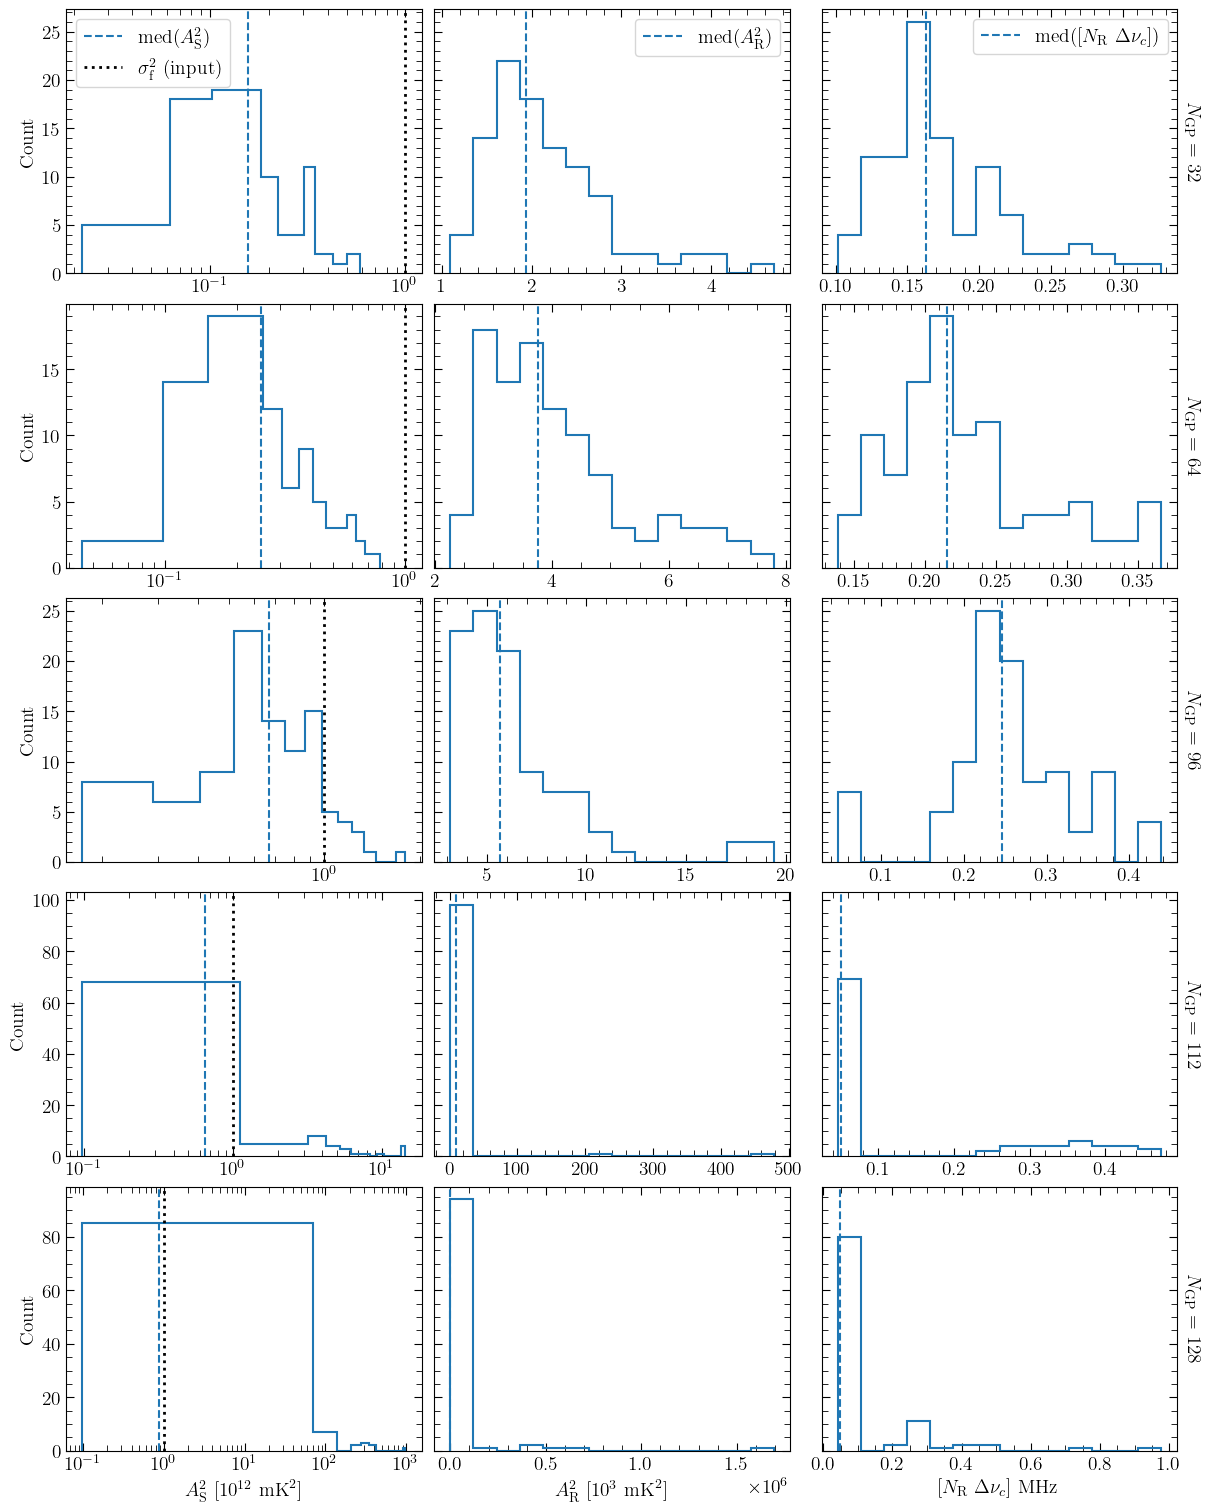

In [30]:
import numpy as np
import matplotlib.pyplot as plt
# ---- NN list ----
NN_list = [32, 64, 96, 112, 128]
nN = len(NN_list)
# ---- SCALE FACTORS ----
scale_AS2 = 1e12
scale_AF2 = 1e3
scale_ell = 1
# ---- Input simulated foreground variance (Section 2.2): sigma_f^2 = 1e12 mK^2 ----
sigma_f2 = 1e12
# ---- FIGURE: rows = NN, cols = params ----
# sharey='row' keeps the y-axis scale consistent within each NN_GP row,
# which is the only place sharing counts actually makes sense (different
# rows can have very different sample sizes / bin counts).
fig, axes = plt.subplots(nN, 3, figsize=(12, 3 * nN), sharey='row')
for i, NN_gp in enumerate(NN_list):
    data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
    summaries = data["summaries"]
    # =========================
    # Column 0: A_S^2
    # =========================
    A_S = np.array([s["amp_smooth"] for s in summaries])
    AS2 = A_S
    med_AS2 = np.median(AS2)
    AS2_plot = AS2 / scale_AS2
    ax = axes[i, 0]
    bins = np.linspace(AS2_plot.min(), AS2_plot.max(), 15)
    ax.hist(AS2_plot, bins=bins, histtype='step', linewidth=1.5)
    ax.axvline(med_AS2 / scale_AS2, linestyle='--', linewidth=1.5,
               label=r"$\mathrm{med}(A_{\mathrm S}^2)$")
    ax.axvline(sigma_f2 / scale_AS2, linestyle=':', linewidth=2.0, color='k',
               label=r"$\sigma_{\mathrm f}^2\ (\mathrm{input})$")
    ax.set_xscale('log')
    if i == 0:
        ax.legend()
    # Row label (N_GP=...) placed outside the right edge of the LAST column,
    # not fighting with the y-axis "Count" label on the left.
    axes[i, 2].annotate(
        rf"$N_{{\rm GP}}={NN_gp}$",
        xy=(1.02, 0.5), xycoords='axes fraction',
        rotation=270, va='center', ha='left', 
    )
    # =========================
    # Column 1: A_R^2
    # =========================
    # amp_fast, as stored, is rescaled by y_res_std**2 (the post-fit residual
    # variance) inside the GP-fitting code. Since the GP itself is normalized
    # only once, by y_std, we convert amp_fast back onto the same y_std**2
    # basis as amp_smooth here -- this is a unit conversion, not a comparison,
    # so y_std/y_res_std are used only internally and never plotted/reported.
    A_F       = np.array([s["amp_fast"] for s in summaries])
    y_std     = np.array([s["y_std"] for s in summaries])
    y_res_std = np.array([s["y_res_std"] for s in summaries])
    AF2 = A_F * (y_std**2 / y_res_std**2)
    med_AF2 = np.median(AF2)
    AF2_plot = AF2 / scale_AF2
    ax = axes[i, 1]
    bins = np.linspace(AF2_plot.min(), AF2_plot.max(), 15)
    ax.hist(AF2_plot, bins=bins, histtype='step', linewidth=1.5)
    ax.axvline(med_AF2 / scale_AF2, linestyle='--', linewidth=1.5,
               label=r"$\mathrm{med}(A_{\mathrm R}^2)$")
    if i == 0:
        ax.legend()
    # =========================
    # Column 2: ell_fast
    # =========================
    ell_fast = np.array([s["ell_fast"] for s in summaries]) * dnuc
    med_ell = np.median(ell_fast)
    ell_plot = ell_fast / scale_ell
    ax = axes[i, 2]
    bins = np.linspace(ell_plot.min(), ell_plot.max(), 15)
    ax.hist(ell_plot, bins=bins, histtype='step', linewidth=1.5)
    ax.axvline(med_ell / scale_ell, linestyle='--', linewidth=1.5,
               label=r"$\mathrm{med}([N_{\mathrm R}~\Delta\nu_c])$")
    if i == 0:
        ax.legend()
    # Only the leftmost column gets a "Count" label, once per row.
    axes[i, 0].set_ylabel(r"$\mathrm{Count}$")
# ---- X LABELS (bottom row only) ----
axes[-1, 0].set_xlabel(r"$A_{\mathrm S}^2\ [10^{12}\ \mathrm{mK}^2]$")
axes[-1, 1].set_xlabel(r"$A_{\mathrm R}^2\ [10^{3}\ \mathrm{mK}^2]$")
axes[-1, 2].set_xlabel(r"$[N_{\rm R}~\Delta\nu_c]\ \mathrm{MHz}$")
# plt.tight_layout(rect=(0, 0, 0.97, 1))  # leave room for the row labels on the right
plt.savefig("gpfit/optimised_hyperparameters.pdf")
plt.show()

In [29]:
# import numpy as np
# import matplotlib.pyplot as plt
# NN_list = [32, 64, 96, 112, 128]
# # storage
# med_AS2, lo_AS2, hi_AS2 = [], [], []
# med_yv,  lo_yv,  hi_yv  = [], [], []
# med_AF2,  lo_AF2,  hi_AF2  = [], [], []
# med_yres, lo_yres, hi_yres = [], [], []
# med_ell, lo_ell, hi_ell = [], [], []
# for NN_gp in NN_list:
#     data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
#     summaries = data["summaries"]
#     # ---- extract ----
#     A_S       = np.array([s["amp_smooth"] for s in summaries])
#     y_std     = np.array([s["y_std"] for s in summaries])
#     A_F       = np.array([s["amp_fast"] for s in summaries])
#     y_res_std = np.array([s["y_res_std"] for s in summaries])
#     ell_fast  = np.array([s["ell_fast"] for s in summaries]) * dnuc
#     y_var     = y_std**2
#     y_res_var = y_res_std**2
#     AF2       = (A_F / y_res_var) * y_var
#     # ---- percentiles ----
#     def p16_50_84(x):
#         return np.percentile(x, [16, 50, 84])
#     # A_S^2
#     p16, p50, p84 = p16_50_84(A_S)
#     lo_AS2.append(p50 - p16)
#     hi_AS2.append(p84 - p50)
#     med_AS2.append(p50)
#     # y_var
#     p16, p50, p84 = p16_50_84(y_var)
#     lo_yv.append(p50 - p16)
#     hi_yv.append(p84 - p50)
#     med_yv.append(p50)
#     # A_F^2
#     p16, p50, p84 = p16_50_84(AF2)
#     lo_AF2.append(p50 - p16)
#     hi_AF2.append(p84 - p50)
#     med_AF2.append(p50)
#     # y_res_var
#     p16, p50, p84 = p16_50_84(y_res_var)
#     lo_yres.append(p50 - p16)
#     hi_yres.append(p84 - p50)
#     med_yres.append(p50)
#     # ell
#     p16, p50, p84 = p16_50_84(ell_fast)
#     lo_ell.append(p50 - p16)
#     hi_ell.append(p84 - p50)
#     med_ell.append(p50)
# # convert to arrays
# med_AS2, lo_AS2, hi_AS2 = map(np.array, (med_AS2, lo_AS2, hi_AS2))
# med_yv,  lo_yv,  hi_yv  = map(np.array, (med_yv,  lo_yv,  hi_yv))
# med_AF2,  lo_AF2,  hi_AF2  = map(np.array, (med_AF2,  lo_AF2,  hi_AF2))
# med_yres, lo_yres, hi_yres = map(np.array, (med_yres, lo_yres, hi_yres))
# med_ell, lo_ell, hi_ell = map(np.array, (med_ell, lo_ell, hi_ell))
# # ---- PLOT ----
# fig, ax = plt.subplots(1, 3, figsize=(12,4))
# # =====================
# # A_S^2
# # =====================
# ax[0].errorbar(NN_list, med_AS2, yerr=[lo_AS2, hi_AS2],
#                fmt='o-', capsize=3, label=r"$\mathrm{med}(A_S^2)$")
# ax[0].errorbar(NN_list, med_yv, yerr=[lo_yv, hi_yv],
#                fmt='s--', capsize=3, label=r"$\mathrm{med}(\sigma_y^2)$")
# ax[0].set_xlabel(r"$N_{\rm GP}$")
# ax[0].set_ylabel(r"$\mathrm{mK}^2$")
# ax[0].set_yscale('log')
# ax[0].legend()
# # =====================
# # A_R^2
# # =====================
# ax[1].errorbar(NN_list, med_AF2, yerr=[lo_AF2, hi_AF2],
#                fmt='o-', capsize=3, label=r"$\mathrm{med}(A_R^2)$")
# ax[1].errorbar(NN_list, med_yres, yerr=[lo_yres, hi_yres],
#                fmt='s--', capsize=3, label=r"$\mathrm{med}(\sigma_{\rm res}^2)$")
# ax[1].set_xlabel(r"$N_{\rm GP}$")
# ax[1].legend()
# ax[1].set_yscale('log')
# # =====================
# # ell
# # =====================
# ax[2].errorbar(NN_list, med_ell, yerr=[lo_ell, hi_ell],
#                fmt='o-', capsize=3, 
#                label=r"$\mathrm{med}([N_{\rm R}~\Delta\nu_c])$")
# ax[2].set_xlabel(r"$N_{\rm GP}$")
# ax[2].set_ylabel(r"${\rm MHz}$")
# ax[2].legend()
# plt.tight_layout()
# plt.savefig("gpfit/hyperparameter_summary.pdf")
# plt.show()

In [18]:
np.diff(med_yv)

array([0., 0., 0., 0.])

In [31]:
# def fmt(val, lo, hi, scale=1):
#     v = val / scale
#     l = lo  / scale
#     h = hi  / scale
#     return rf"${v:.2f}_{{-{l:.2f}}}^{{+{h:.2f}}}$"
    
# scale_AS2  = 1e11
# scale_AF2  = 1e3
# scale_yres = 1e3

# # representative value for caption (since it's constant)
# sigma_y_med = np.median(med_yv)

# print(r"\begin{table}")
# print(r"\centering")

# # spacing
# print(r"\renewcommand{\arraystretch}{1.4}")
# print(r"\setlength{\tabcolsep}{8pt}")

# print(rf"\caption{{GP hyperparameter summary (median with 16--84\% intervals). "
#       rf"$\sigma_y^2 = {sigma_y_med/scale_AS2:.2f}\times 10^{{11}}\ \mathrm{{mK}}^2$ "
#       rf"(approximately constant across $N_{{\rm GP}}$).}}")

# print(r"\begin{tabular}{c c c c}")
# print(r"\hline")
# print(r"$N_{\rm GP}$ & $A_S^2\ [10^{11}\ \mathrm{mK}^2]$ & $A_R^2\ [10^{3}\ \mathrm{mK}^2]$ & $ [N_{\rm R}~\Delta\nu_c]\ (\mathrm{MHz})$ \\")
# print(r"\hline")

# for i, NN in enumerate(NN_list):
#     row = (
#         f"{NN} & "
#         f"{fmt(med_AS2[i], lo_AS2[i], hi_AS2[i], scale_AS2)} & "
#         f"{fmt(med_AF2[i], lo_AF2[i], hi_AF2[i], scale_AF2)} & "
#         f"{fmt(med_ell[i], lo_ell[i], hi_ell[i])} \\\\"
#     )
#     print(row)

# print(r"\hline")
# print(r"\end{tabular}")
# print(r"\end{table}")

In [32]:
import numpy as np

NN_list = [32, 64, 96, 112, 128]
# storage
med_AS2, lo_AS2, hi_AS2 = [], [], []
med_AR2, lo_AR2, hi_AR2 = [], [], []
med_ell, lo_ell, hi_ell = [], [], []

def p16_50_84(x):
    return np.percentile(x, [16, 50, 84])

for NN_gp in NN_list:
    data = np.load(f"gpfit/gp_fit_summaries_NN_{NN_gp}.npz", allow_pickle=True)
    summaries = data["summaries"]
    # ---- extract ----
    A_S       = np.array([s["amp_smooth"] for s in summaries])
    A_F       = np.array([s["amp_fast"] for s in summaries])
    y_std     = np.array([s["y_std"] for s in summaries])
    y_res_std = np.array([s["y_res_std"] for s in summaries])
    ell_fast  = np.array([s["ell_fast"] for s in summaries]) * dnuc
    # amp_fast is rescaled by y_res_std**2 inside the GP-fitting code; convert
    # it back onto the same y_std**2 basis as amp_smooth (unit conversion only,
    # y_std/y_res_std are not reported or plotted elsewhere).
    A_R = A_F * (y_std**2 / y_res_std**2)
    # A_S^2
    p16, p50, p84 = p16_50_84(A_S)
    lo_AS2.append(p50 - p16)
    hi_AS2.append(p84 - p50)
    med_AS2.append(p50)
    # A_R^2
    p16, p50, p84 = p16_50_84(A_R)
    lo_AR2.append(p50 - p16)
    hi_AR2.append(p84 - p50)
    med_AR2.append(p50)
    # ell
    p16, p50, p84 = p16_50_84(ell_fast)
    lo_ell.append(p50 - p16)
    hi_ell.append(p84 - p50)
    med_ell.append(p50)

# convert to arrays
med_AS2, lo_AS2, hi_AS2 = map(np.array, (med_AS2, lo_AS2, hi_AS2))
med_AR2, lo_AR2, hi_AR2 = map(np.array, (med_AR2, lo_AR2, hi_AR2))
med_ell, lo_ell, hi_ell = map(np.array, (med_ell, lo_ell, hi_ell))

def fmt(val, lo, hi, scale=1):
    v = val / scale
    l = lo  / scale
    h = hi  / scale
    return rf"${v:.2f}_{{-{l:.2f}}}^{{+{h:.2f}}}$"

scale_AS2 = 1e11
scale_AR2 = 1e3

print(r"\begin{table}")
print(r"\centering")
print(r"\renewcommand{\arraystretch}{1.4}")
print(r"\setlength{\tabcolsep}{8pt}")
print(r"\caption{GP hyperparameter summary (median with 16--84\% intervals).}")
print(r"\begin{tabular}{c c c c}")
print(r"\hline")
print(r"$N_{\rm GP}$ & $A_S^2\ [10^{11}\ \mathrm{mK}^2]$ & $A_R^2\ [10^{3}\ \mathrm{mK}^2]$ & $ [N_{\rm R}~\Delta\nu_c]\ (\mathrm{MHz})$ \\")
print(r"\hline")
for i, NN in enumerate(NN_list):
    row = (
        f"{NN} & "
        f"{fmt(med_AS2[i], lo_AS2[i], hi_AS2[i], scale_AS2)} & "
        f"{fmt(med_AR2[i], lo_AR2[i], hi_AR2[i], scale_AR2)} & "
        f"{fmt(med_ell[i], lo_ell[i], hi_ell[i])} \\\\"
    )
    print(row)
print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")

\begin{table}
\centering
\renewcommand{\arraystretch}{1.4}
\setlength{\tabcolsep}{8pt}
\caption{GP hyperparameter summary (median with 16--84\% intervals).}
\begin{tabular}{c c c c}
\hline
$N_{\rm GP}$ & $A_S^2\ [10^{11}\ \mathrm{mK}^2]$ & $A_R^2\ [10^{3}\ \mathrm{mK}^2]$ & $ [N_{\rm R}~\Delta\nu_c]\ (\mathrm{MHz})$ \\
\hline
32 & $1.57_{-0.62}^{+1.64}$ & $1.94_{-0.37}^{+0.74}$ & $0.16_{-0.03}^{+0.05}$ \\
64 & $2.51_{-0.99}^{+1.80}$ & $3.76_{-0.86}^{+1.58}$ & $0.22_{-0.04}^{+0.08}$ \\
96 & $6.70_{-2.36}^{+2.93}$ & $5.68_{-1.67}^{+2.81}$ & $0.25_{-0.04}^{+0.08}$ \\
112 & $6.48_{-2.57}^{+32.38}$ & $9.66_{-4.42}^{+6.94}$ & $0.05_{-0.00}^{+0.30}$ \\
128 & $8.70_{-4.33}^{+586.31}$ & $42.55_{-34.77}^{+6718.75}$ & $0.05_{-0.00}^{+0.21}$ \\
\hline
\end{tabular}
\end{table}
